# NiSpace workflows

The notebooks so far have built up the NiSpace pipeline step by step — `fit()`, `transform_y()`, `clean_y()`, `colocalize()`, `permute()`, `plot()`. That level of control is great when you need flexibility. But for standard analyses, NiSpace provides **workflow functions** that run the complete pipeline in a single call.

Three workflows are available:

| Function | Question answered | Null model |
|----------|-------------------|------------|
| `simple_colocalization()` | Does this map colocalize with reference maps? | Surrogate map permutation |
| `group_comparison()` | Do brain alterations in this group colocalize with reference maps? | Group label permutation |
| `simple_xsea()` | Is the average colocalization with a set of maps higher than expected by chance? | Surrogate map permutation |

All workflows return `(colocalizations, p_values, q_values, nsp_object)`. The `nsp_object` is a fully fitted `NiSpace` instance — you can call any of the methods you've seen in previous notebooks on it.

In [1]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import pandas as pd
import numpy as np

## `simple_colocalization()` — single map

The simplest workflow: you have one (or a few) group-level brain maps and want to test whether they colocalize with a set of reference maps.

INFO | 22/05/26 14:50:13 | nispace.workflows: Loading integrated pet dataset as X data.
INFO | 22/05/26 14:50:13 | nispace.datasets: Loading pet maps.
INFO | 22/05/26 14:50:13 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.
INFO | 22/05/26 14:50:13 | nispace.datasets: Filtering maps by collection.
INFO | 22/05/26 14:50:13 | nispace.datasets: Loading data parcellated with 'Schaefer200'
The NiSpace "PET" dataset is based on openly available nuclear imaging maps largely accessed via neuromaps 
(https://neuromaps-main.readthedocs.io/). If requested in the varying original spaces and resolutions (termed "MNI152", 
"fsaverageOriginal", or "fsLROriginal"), the maps are downloaded directly from the source and cached locally. If, as is highly 
recommended, the maps are requested in a defined space ("MNI152NLin2009cAsym", "MNI152NLin6Asym", "fsaverage", or "fsLR"), 
they are downloaded from the NiSpace-data GitHub repo (find them in `~HOME/nispace-data/refere

Parcellating (4 proc): 100%|██████████| 1/1 [00:00<00:00, 53.39it/s]


INFO | 22/05/26 14:50:18 | nispace.api: Got 'y' data for 1 x 200 parcels.
INFO | 22/05/26 14:50:18 | nispace.api: Z-standardizing 'X' data.
INFO | 22/05/26 14:50:18 | nispace.api: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 22/05/26 14:50:18 | nispace.api: Running 'spearman' colocalization.
INFO | 22/05/26 14:50:18 | nispace.api: Pre-ranking X and Y data.


Colocalizing (spearman, 4 proc): 100%|██████████| 1/1 [00:00<00:00, 2023.30it/s]


INFO | 22/05/26 14:50:21 | nispace.api: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 22/05/26 14:50:21 | nispace.api: Permutation of: X maps.
INFO | 22/05/26 14:50:21 | nispace.api: Using default null method 'alexander_bloch' (parcellation null space: 'fsLR').
INFO | 22/05/26 14:50:21 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.
INFO | 22/05/26 14:50:21 | nispace.api: Loading observed colocalizations (method = 'spearman').
INFO | 22/05/26 14:50:21 | nispace.core.permute: No null maps found.
INFO | 22/05/26 14:50:21 | nispace.core.permute: Generating null maps (n = 10000, null_method = 'alexander_bloch').
INFO | 22/05/26 14:50:21 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsaverage'.
INFO | 22/05/26 14:50:21 | nispace.nulls: Null map generation: Assuming n = 29 data vector(s) for n = 200 parcels.
INFO | 22/05/26 14:50:21 | nispace.nulls: Using provided precomputed spin matrix.


Spin null maps: 100%|██████████| 29/29 [00:01<00:00, 23.16it/s]

INFO | 22/05/26 14:50:22 | nispace.nulls: Null data generation finished.
INFO | 22/05/26 14:50:22 | nispace.core.permute: Z-standardizing null maps.



Null colocalizations (spearman, 4 proc): 100%|██████████| 10000/10000 [00:00<00:00, 10266.16it/s]


INFO | 22/05/26 14:50:29 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'upper'}).
INFO | 22/05/26 14:50:31 | nispace.plotting: Significance annotation: 1/29 p_uncorrected < 0.05, 0/29 p_fdrbh < 0.05


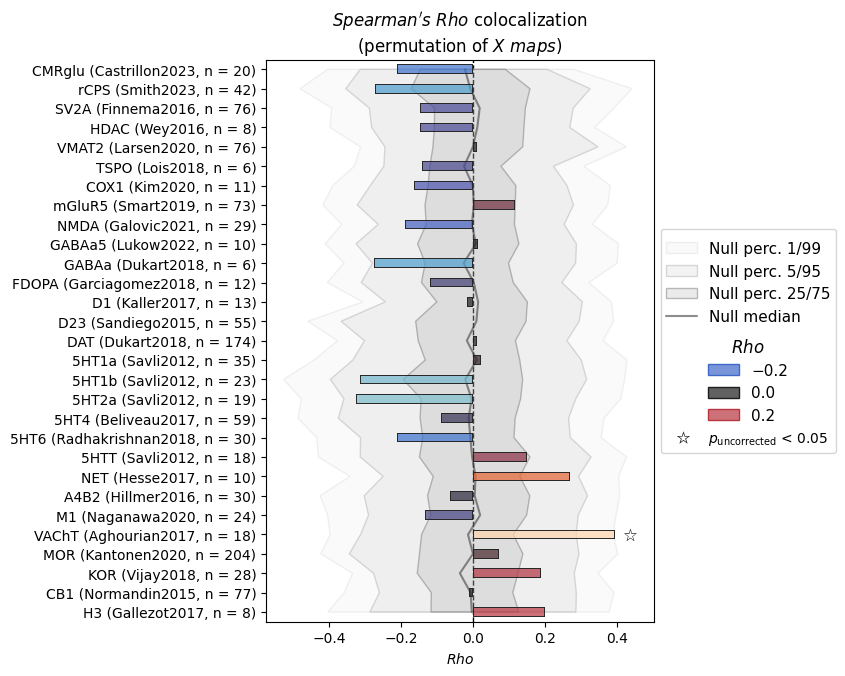

In [2]:
from nispace.workflows import simple_colocalization
from nispace.io import load_img

pain_map = load_img("neuroquery/pain.nii.gz")

colocs, p_values, q_values, nsp = simple_colocalization(
    y={"Pain": pain_map},  # dict key becomes the map label; can also be just the image
    x="pet",               # string shortcut: automatically fetches the PET reference dataset
    x_collection="UniqueTracers",
    parcellation="Schaefer200",
    colocalization_method="spearman",
    permute_kwargs={"p_tails": "upper"},  # directional test
    mc_method="fdr_bh",
    n_perm=10000,
    seed=42,
    n_proc=4
)

In [3]:
# results are standard DataFrames
results = pd.concat([colocs, p_values, q_values], keys=["rho", "p", "q"])
results.droplevel(1).T.sort_values(by="p").head(8)

rho  \
set                         map                                                            
Noradrenaline/Acetylcholine target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghour...  0.396341   
                            target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017      0.271602   
Histamine                   target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallez...  0.200932   
Opiods/Endocannabinoids     target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vija...  0.189344   
Glutamate                   target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smar...  0.118618   
Serotonin                   target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012    0.149997   
Opiods/Endocannabinoids     target-MOR_tracer-carfentanil_n-204_dx-hc_pub-k...  0.074165   
Dopamine                    target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018  0.010763   

                                                                                     p  \
set                         map                                                          
Noradrenaline/Acetylcholine target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghour...  0.0089   
                            target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017      0.0643   
Histamine                   target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallez...  0.1365   
Opiods/Endocannabinoids     target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vija...  0.1552   
Glutamate                   target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smar...  0.2490   
Serotonin                   target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012    0.2633   
Opiods/Endocannabinoids     target-MOR_tracer-carfentanil_n-204_dx-hc_pub-k...  0.3586   
Dopamine                    target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018  0.4518   

                                                                                      q  
set                         map                                                          
Noradrenaline/Acetylcholine target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghour...  0.25810  
                            target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017      0.93235  
Histamine                   target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallez...  0.94600  
Opiods/Endocannabinoids     target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vija...  0.94600  
Glutamate                   target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smar...  0.94600  
Serotonin                   target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012    0.94600  
Opiods/Endocannabinoids     target-MOR_tracer-carfentanil_n-204_dx-hc_pub-k...  0.94600  
Dopamine                    target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018  0.94600

INFO | 22/05/26 14:50:32 | nispace.plotting: Significance annotation: 1/29 p_uncorrected < 0.05, 0/29 p_fdr_bh < 0.05


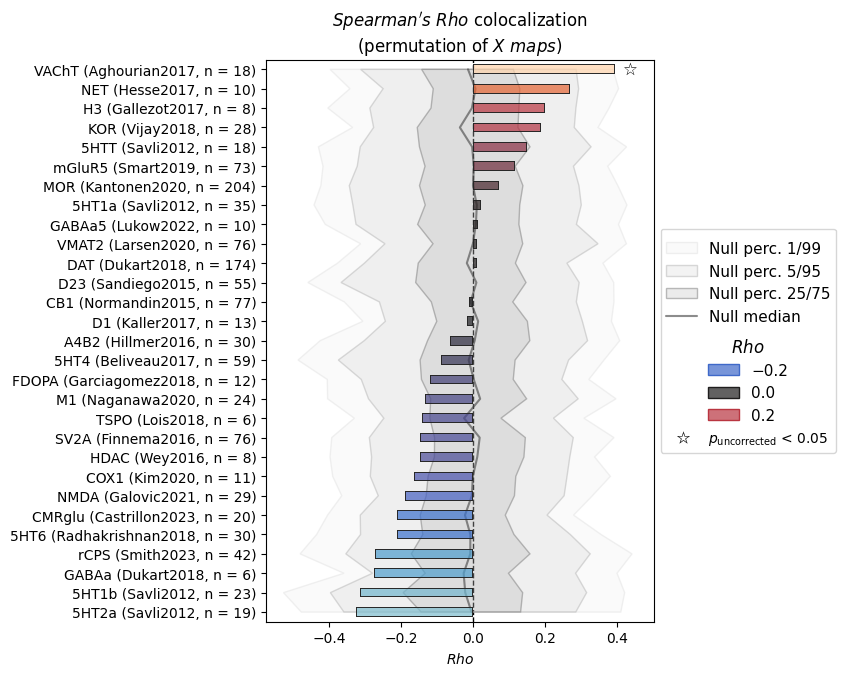

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x30f0659a0>)

In [4]:
# the nsp_object is a fully fitted NiSpace object — you can use all methods on it
nsp.plot(mc_method="fdr_bh", sort_by="coloc")

## `group_comparison()` — patient vs. control

The group comparison workflow handles the full pipeline for individual subject data: covariate regression, effect size computation, colocalization, and group label permutation.

The `design` argument is a DataFrame with one row per subject. The column `"groups"` is required; any other columns are treated as covariates to regress out. A `"site"` column triggers ComBat harmonization if `combat=True`.

We use the anorexia nervosa example dataset here.

> **Note:** This dataset is **simulated** and not intended for scientific use — it exists purely for demonstration purposes.

INFO | 22/05/26 14:50:33 | nispace.datasets: Loading example dataset: 'anorexianervosa', parcellated with: Schaefer200.
INFO | 22/05/26 14:50:33 | nispace.workflows: Loading integrated pet dataset as X data.
INFO | 22/05/26 14:50:33 | nispace.datasets: Loading pet maps.
INFO | 22/05/26 14:50:33 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.
INFO | 22/05/26 14:50:33 | nispace.datasets: Filtering maps by collection.
INFO | 22/05/26 14:50:33 | nispace.datasets: Loading data parcellated with 'Schaefer200'
The NiSpace "PET" dataset is based on openly available nuclear imaging maps largely accessed via neuromaps 
(https://neuromaps-main.readthedocs.io/). If requested in the varying original spaces and resolutions (termed "MNI152", 
"fsaverageOriginal", or "fsLROriginal"), the maps are downloaded directly from the source and cached locally. If, as is highly 
recommended, the maps are requested in a defined space ("MNI152NLin2009cAsym", "MNI152NLin6Asym", 

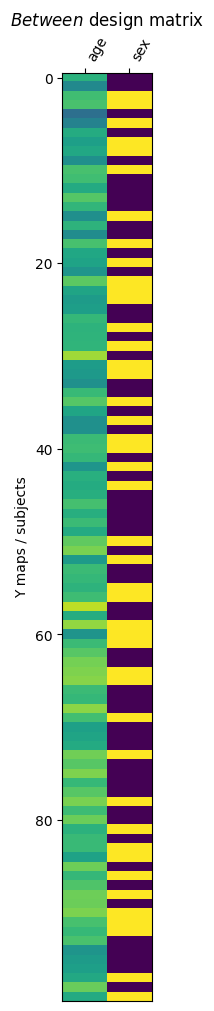

INFO | 22/05/26 14:50:33 | nispace.core.clean_y: Protecting 1 variable(s) during regression: ['groups_HC'].
INFO | 22/05/26 14:50:33 | nispace.core.clean_y: Regressing 2 between covariate(s) from Y.


Regressing 2 between covariate(s) from Y, protecting 1 variable(s) (4 proc): 100%|██████████| 200/200 [00:02<00:00, 87.23it/s]
Colocalizing (spearman, 4 proc): 100%|██████████| 1/1 [00:00<00:00, 1122.37it/s]

INFO | 22/05/26 14:50:35 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.



Null colocalizations (spearman, 4 proc): 100%|██████████| 5000/5000 [00:00<00:00, 26862.66it/s]


INFO | 22/05/26 14:50:37 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).
INFO | 22/05/26 14:50:37 | nispace.plotting: Significance annotation: 5/29 p_uncorrected < 0.05, 4/29 p_fdrbh < 0.05


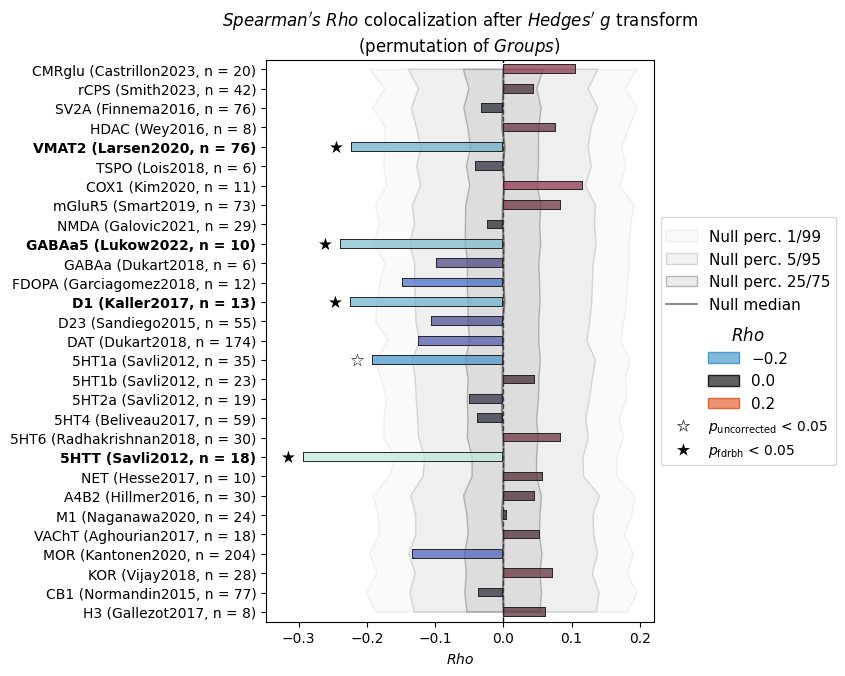

In [5]:
from nispace.workflows import group_comparison
from nispace.datasets import fetch_example

# load the anorexia nervosa example data
an_data = fetch_example("anorexianervosa", parcellation="Schaefer200")

# extract group labels
groups = an_data.index.str.extract(r'(AN|HC)$')[0].values

# generate synthetic covariates
rng = np.random.default_rng(42)
age = np.concatenate([rng.normal(25, 5, 50), rng.normal(30, 5, 50)])
sex = rng.integers(0, 2, 100)

# design matrix: groups column is mandatory, others are covariates
design = pd.DataFrame({
    "groups": groups,
    "age": age,
    "sex": sex
}, index=an_data.index)

colocs_gc, p_gc, q_gc, nsp_gc = group_comparison(
    y=an_data,
    design=design,
    x="pet",
    x_collection="UniqueTracers",
    parcellation="Schaefer200",
    comparison_method="hedges(a,b)",
    colocalization_method="spearman",
    mc_method="fdr_bh",
    n_perm=5000,
    seed=42,
    n_proc=4
)

In [6]:
# top results
gc_results = pd.concat([colocs_gc, p_gc, q_gc], keys=["rho", "p", "q"])
gc_results.droplevel(1).T.sort_values(by="p").head(8)

rho  \
set       map                                                            
Serotonin target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   -0.293667   
General   target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020 -0.222660   
GABA      target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lu... -0.239409   
Dopamine  target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller... -0.225104   
Serotonin target-5HT1a_tracer-way100635_n-35_dx-hc_pub-sa... -0.192459   
Dopamine  target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g... -0.149024   
          target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018 -0.124542   
Immunity  target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020      0.116124   

                                                                   p         q  
set       map                                                                   
Serotonin target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012    0.0002  0.005800  
General   target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020  0.0024  0.023200  
GABA      target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lu...  0.0024  0.023200  
Dopamine  target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller...  0.0032  0.023200  
Serotonin target-5HT1a_tracer-way100635_n-35_dx-hc_pub-sa...  0.0160  0.092800  
Dopamine  target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g...  0.0532  0.257133  
          target-DAT_tracer-fpcit_n-174_dx-hc_pub-dukart2018  0.0944  0.363467  
Immunity  target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020      0.1112  0.363467

INFO | 22/05/26 14:50:38 | nispace.plotting: Significance annotation: 5/29 p_uncorrected < 0.05, 4/29 p_fdr_bh < 0.05


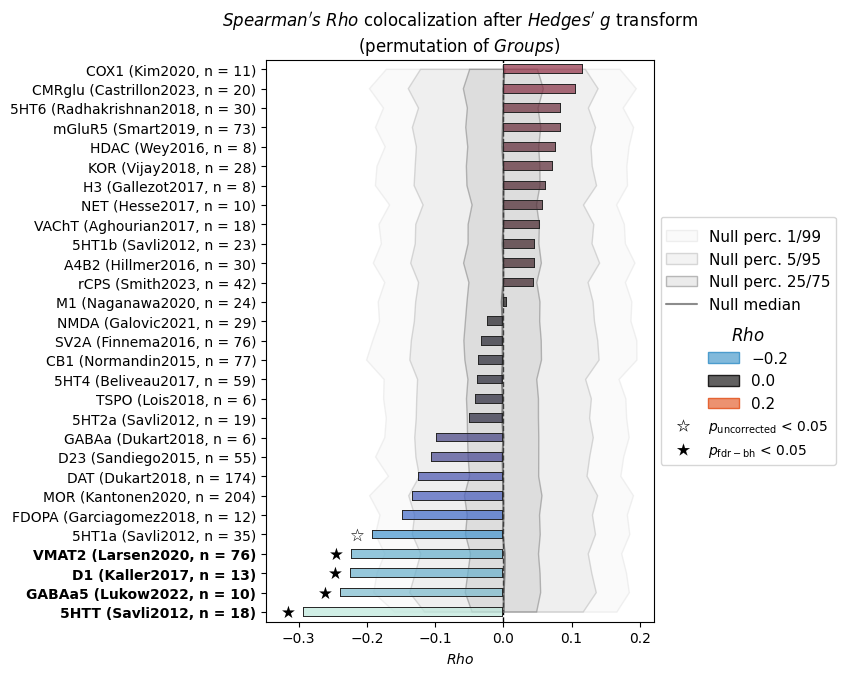

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization after $Hedges'\\ g$ transform\n(permutation of $Groups$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x31cd55cd0>)

In [7]:
nsp_gc.plot(sort_by="coloc", mc_method="fdr_bh")

WARNING | 22/05/26 14:50:39 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!
INFO | 22/05/26 14:50:39 | nispace.plotting: brainplot: threshold='auto' → 0.0022586341947317123
INFO | 22/05/26 14:50:39 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.
INFO | 22/05/26 14:50:39 | nispace.core.parcellation: Parcellation 'Schaefer200': active space set to 'MNI152NLin2009cAsym' (was 'fsLR').
INFO | 22/05/26 14:50:39 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


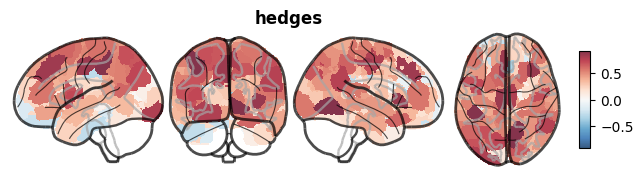

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

In [8]:
# effect size map on the brain
nsp_gc.plot_brain(data="Y", symmetric_cmap=True)

## `simple_xsea()` — X-Set Enrichment Analysis

XSEA tests whether the average colocalization between your input map and a *set* of reference maps is higher than expected by chance. This is useful when you have reference maps organized into biologically meaningful groups (e.g., gene expression grouped by cell type).

We'll cover XSEA in much more detail in [Notebook 10](intro10_xsea.ipynb). Here's a minimal example:

In [10]:
from nispace.workflows import simple_xsea
from nispace.datasets import fetch_reference

# use the anorexia nervosa Hedges' g map we computed above
hedges_g = nsp_gc.get_y()

# test against mRNA gene expression sets (cell type markers)
colocs_xsea, p_xsea, q_xsea, nsp_xsea = simple_xsea(
    y=hedges_g,
    x="mrna",          # mRNA gene expression reference
    x_collection="CellTypesSilettiSuperclusters",  # predefined cell type sets
    parcellation="Schaefer200",  
    colocalization_method="spearman",
    mc_method="fdr_bh",
    n_perm=5000,
    seed=42,
    n_proc=4
)

INFO | 22/05/26 14:51:34 | nispace.workflows: Loading integrated mrna dataset as X data.
INFO | 22/05/26 14:51:34 | nispace.datasets: Loading mrna maps.
INFO | 22/05/26 14:51:34 | nispace.datasets: Loading integrated collection 'CellTypesSilettiSuperclusters' for dataset 'mrna'.
INFO | 22/05/26 14:51:34 | nispace.datasets: Filtering maps by collection.
INFO | 22/05/26 14:51:35 | nispace.datasets: Loading data parcellated with 'Schaefer200'
The NiSpace "mRNA" dataset is based on Allen Human Brain Atlas (AHBA) gene expression data published in Hawrylycz et al., 
2012 (https://doi.org/10.1038/nature11405). The dataset consists of mRNA expression data from postmortem brain tissue of 
six donors, mapped onto MNI or fsaverage parcels using the abagen toolbox (Markello et al., 2021, https://doi.org/10.7554/eLife.72129).
The data was extracted using abagen.get_expression_data(..., lr_mirror="bidirectional"), considering parcel hemisphere and 
cortical vs. subcortical location. Only genes that 

Colocalizing (spearman, 4 proc): 100%|██████████| 1/1 [00:00<00:00, 1362.67it/s]

INFO | 22/05/26 14:51:35 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.
INFO | 22/05/26 14:51:35 | nispace.core.permute: No null maps found.
INFO | 22/05/26 14:51:35 | nispace.core.permute: Generating null maps (n = 5000, null_method = 'alexander_bloch').
INFO | 22/05/26 14:51:35 | nispace.nulls: Null map generation: Assuming n = 1 data vector(s) for n = 200 parcels.
INFO | 22/05/26 14:51:35 | nispace.nulls: Using provided precomputed spin matrix.



Spin null maps: 100%|██████████| 1/1 [00:00<00:00, 35.08it/s]

INFO | 22/05/26 14:51:35 | nispace.nulls: Null data generation finished.



Null colocalizations (spearman, 4 proc): 100%|██████████| 5000/5000 [00:02<00:00, 1684.99it/s]


INFO | 22/05/26 14:51:39 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).
WARNING | 22/05/26 14:51:39 | nispace.workflows: Skipping plot: 548 X maps exceed the default limit of 50. Call nsp.plot(n_categories=548, sort_by='abs_z') to plot manually.


INFO | 22/05/26 14:51:40 | nispace.plotting: Significance annotation: 1/29 p_uncorrected < 0.05, 0/29 p_fdr_bh < 0.05


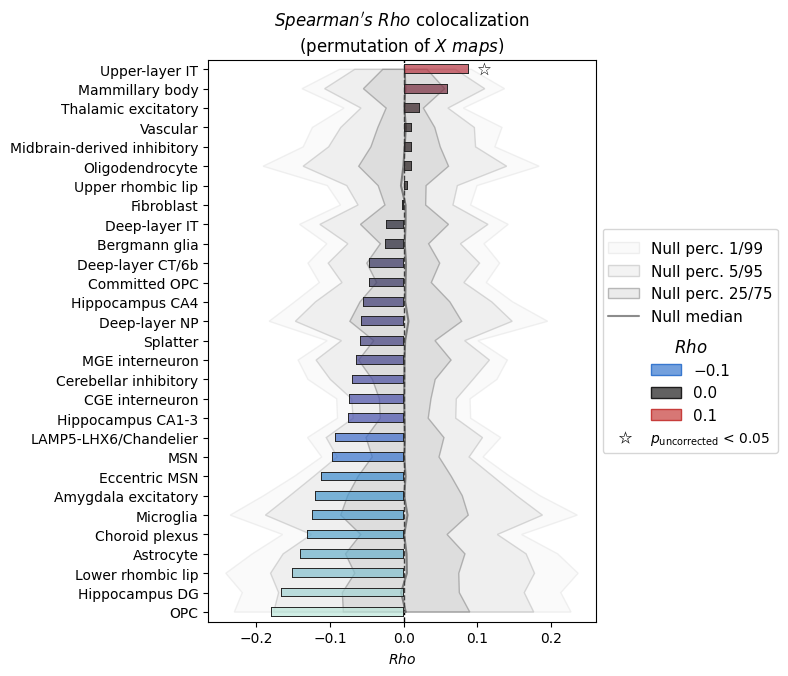

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x359a199d0>)

In [11]:
nsp_xsea.plot(sort_by="coloc", mc_method="fdr_bh")

## When to use workflows vs. the object API

| Situation | Recommended approach |
|-----------|---------------------|
| Quick analysis, standard pipeline | Workflow function |
| Need full control over each step | Object API (`NiSpace` class) |
| Custom preprocessing sequence | Object API |
| Running the same analysis on many maps | Object API (reuse the fitted object) |
| Embedding in a larger pipeline | Object API |
| Teaching/demonstration | Workflow (less boilerplate) |

The two approaches are not exclusive. You can start with a workflow, inspect the returned `nsp_object`, and then call additional methods on it — for example to plot with different settings, or to run additional permutation tests.

## Summary

All three workflows return `(colocalizations, p_values, q_values, nsp_object)` and accept these common arguments:

```python
simple_colocalization(y, x="pet", x_collection=None, parcellation="Schaefer200",
                      colocalization_method="spearman", mc_method="meff",
                      n_perm=10000, seed=None, n_proc=1)

group_comparison(y, design, x="pet", comparison_method="hedges(a,b)",
                 colocalization_method="spearman", mc_method="meff",
                 n_perm=10000, seed=None, n_proc=1)

simple_xsea(y, x="mrna", x_collection=None, parcellation="Schaefer200",
            colocalization_method="spearman", mc_method="meff",
            n_perm=10000, seed=None, n_proc=1)
```

Next: [Notebook 10](intro10_xsea.ipynb) dives deep into X-Set Enrichment Analysis.